Saving car data.csv to car data.csv
0.8488707839193155


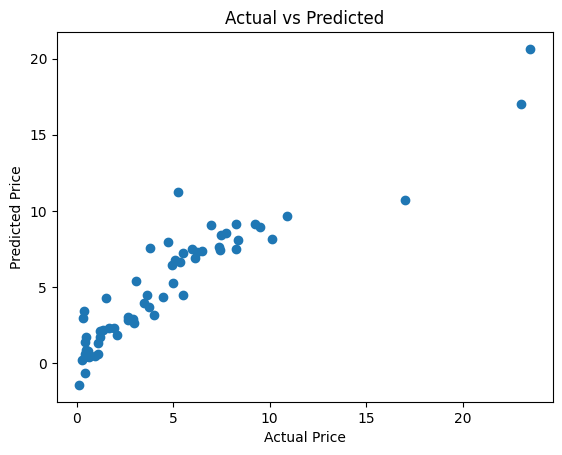

In [4]:
import pandas as pd
from google.colab import files
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
import matplotlib.pyplot as plt

uploaded = files.upload()

filename = list(uploaded.keys())[0]

df = pd.read_csv(filename)

df['Current_Year'] = 2026
df['Age'] = df['Current_Year'] - df['Year']

df.drop(['Year', 'Current_Year', 'Car_Name'], axis=1, inplace=True)

df = pd.get_dummies(df, drop_first=True)

X = df.drop('Selling_Price', axis=1)
y = df['Selling_Price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print(r2_score(y_test, y_pred))

plt.scatter(y_test, y_pred)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted")
plt.show()